In [1]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score

# KNN quitando cols muy sesgadas y fechas y cerrando rangos (outliers)

Modelo que prediga  si un cliente está Completamente satisfecho o no.  
Usaremos el REVIEW SCORE y lo vamos a transformar en una variable binaria con el siguiente criterio: 
- Review Score = 1,2,3,4, entonces no ha quedado completamente Satisfecho
- Review Score = 5, entonces el cliente ha quedado completamente Satisfecho

0. Importamos datos, se trata de la tabla base que hemos construido.
   
Partimos de 26 columnas, SIN NULOS ya:


 0.    Unnamed: 0                     97916 non-null  int64  
 1.    order_id                       97916 non-null  object 
 2.    media_review_score             97916 non-null  int64  
 3.    fecha_ultima_review            97916 non-null  object 
 4.    order_purchase_timestamp       97916 non-null  object 
 5.    delivered_status               97916 non-null  int64  
 6.    delay_time                     97916 non-null  int64  
 7.    customer_unique_id             97916 non-null  object 
 8.    customer_state                 97916 non-null  object 
 9.    number_payments                97916 non-null  float64
 10.   payment_value_sum              97916 non-null  float64
 11.   payment_type                   97916 non-null  object 
 12.   number_items                   97916 non-null  float64
 13.   total_price                    97916 non-null  float64
 14.   total_freight_value            97916 non-null  float64
 15.   total_diff_items               97916 non-null  float64
 16.   product_id                     97916 non-null  object 
 17.   seller_id                      97916 non-null  object 
 18.   product_description_lenght     97916 non-null  float64
 19.   product_photos_qty             97916 non-null  float64
 20.   product_weight_g               97916 non-null  float64
 21.   product_length_cm              97916 non-null  float64
 22.   product_height_cm              97916 non-null  float64
 23.   product_width_cm               97916 non-null  float64
 24.   product_category_name_english  97916 non-null  object 
 25.   seller_state                   97916 non-null  object 


In [2]:
data = pd.read_csv('final_data (3).csv', sep = ',')
data.head()

,Unnamed: 0,order_id,media_review_score,fecha_ultima_review,order_purchase_timestamp,delivered_status,delay_time,customer_unique_id,customer_state,number_payments,...,product_id,seller_id,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,seller_state
0,0,00010242fe8c5a6d1ba2dd792cb16214,5,2017-09-21,2017-09-13,1,9,871766c5855e863f6eccc05f988b23cb,Southeast,1.0,...,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,598.0,4.0,650.0,28.0,9.0,14.0,Miscellaneous and Other Items,Southeast
1,1,00018f77f2f0320c557190d7a144bdd3,4,2017-05-13,2017-04-26,1,3,eb28e67c4c0b83846050ddfb8a35d051,Southeast,1.0,...,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,239.0,2.0,30000.0,50.0,30.0,40.0,Miscellaneous and Other Items,Southeast
2,2,000229ec398224ef6ca0657da4fc703e,5,2018-01-23,2018-01-14,1,14,3818d81c6709e39d06b2738a8d3a2474,Southeast,1.0,...,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,695.0,2.0,3050.0,33.0,13.0,33.0,Home and Decoration,Southeast
3,3,00024acbcdf0a6daa1e931b038114c75,4,2018-08-15,2018-08-08,1,6,af861d436cfc08b2c2ddefd0ba074622,Southeast,1.0,...,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,480.0,1.0,200.0,16.0,10.0,15.0,Fashion and Personal Care,Southeast
4,4,00042b26cf59d7ce69dfabb4e55b4fd9,5,2017-03-02,2017-02-04,1,16,64b576fb70d441e8f1b2d7d446e483c5,Southeast,1.0,...,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,409.0,1.0,3750.0,35.0,40.0,30.0,Tools and Construction,South


In [3]:
data.describe()

,Unnamed: 0,media_review_score,delivered_status,delay_time,number_payments,payment_value_sum,number_items,total_price,total_freight_value,total_diff_items,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,97916.000000,97916.000000,97916.000000,97916.000000,97916.000000,97916.000000,97916.000000,97916.000000,97916.000000,97916.000000,97916.000000,97916.000000,97916.000000,97916.000000,97916.000000,97916.000000
mean,49346.970669,4.104467,0.978706,-9.653570,1.044518,160.367686,1.140825,137.534315,22.804160,1.037900,792.743198,2.246180,2122.376282,30.206698,16.573032,23.112341
std,28485.578875,1.330662,0.144363,146.493093,0.380054,219.286727,0.533752,209.483686,21.621084,0.225802,652.534971,1.749662,3786.553368,16.189133,13.377454,11.785387
min,0.000000,1.000000,0.000000,-1000.000000,1.000000,9.590000,1.000000,0.850000,0.000000,1.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,24682.750000,4.000000,1.000000,7.000000,1.000000,61.930000,1.000000,45.900000,13.840000,1.000000,357.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,49343.500000,5.000000,1.000000,12.000000,1.000000,105.280000,1.000000,86.900000,17.160000,1.000000,603.000000,2.000000,700.000000,25.000000,13.000000,20.000000
75%,74024.250000,5.000000,1.000000,17.000000,1.000000,176.760000,1.000000,149.900000,24.010000,1.000000,994.000000,3.000000,1825.000000,38.000000,20.000000,30.000000
max,98672.000000,5.000000,1.000000,147.000000,29.000000,13664.080000,21.000000,13440.000000,1794.960000,8.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000


In [4]:
resumen_unicos = pd.DataFrame({
    'columna': data.columns,
    'nunicos': [data[col].nunique() for col in data.columns],
   })
print(resumen_unicos)

                          columna  nunicos
0                      Unnamed: 0    97916
1                        order_id    97916
2              media_review_score        5
3             fecha_ultima_review      632
4        order_purchase_timestamp      615
5                delivered_status        2
6                      delay_time      197
7              customer_unique_id    94720
8                  customer_state        6
9                 number_payments       20
10              payment_value_sum    27474
11                   payment_type        5
12                   number_items       17
13                    total_price     7587
14            total_freight_value     7666
15               total_diff_items        8
16                     product_id    30802
17                      seller_id     3066
18     product_description_lenght     2952
19             product_photos_qty       19
20               product_weight_g     2188
21              product_length_cm       99
22         

## 1. Buscar columnas con valores nulos y cantidad de nulos en cada una. NO HAY

In [5]:
resumen_nulos = pd.DataFrame({
    'columna': data.columns,
    'nulos': [data[col].isnull().sum() for col in data.columns],
    'porcentaje': [data[col].isnull().mean() * 100 for col in data.columns],
   })
print(resumen_nulos)

                          columna  nulos  porcentaje
0                      Unnamed: 0      0         0.0
1                        order_id      0         0.0
2              media_review_score      0         0.0
3             fecha_ultima_review      0         0.0
4        order_purchase_timestamp      0         0.0
5                delivered_status      0         0.0
6                      delay_time      0         0.0
7              customer_unique_id      0         0.0
8                  customer_state      0         0.0
9                 number_payments      0         0.0
10              payment_value_sum      0         0.0
11                   payment_type      0         0.0
12                   number_items      0         0.0
13                    total_price      0         0.0
14            total_freight_value      0         0.0
15               total_diff_items      0         0.0
16                     product_id      0         0.0
17                      seller_id      0      

## 2. Duplicados (Posterior a cruces de tablas muy recomendable). NO DEBE HABER

In [6]:
# Número de filas duplicadas completas
data.duplicated().sum()

#  filas duplicadas
duplicados_completos = data[data.duplicated()]
duplicados_completos

,Unnamed: 0,order_id,media_review_score,fecha_ultima_review,order_purchase_timestamp,delivered_status,delay_time,customer_unique_id,customer_state,number_payments,...,product_id,seller_id,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,seller_state


In [7]:
cols_usuales = ['order_id', 'product_id', 'customer_unique_id']

duplicados_usuales = data[data.duplicated(subset=cols_usuales, keep=False)]
duplicados_usuales

,Unnamed: 0,order_id,media_review_score,fecha_ultima_review,order_purchase_timestamp,delivered_status,delay_time,customer_unique_id,customer_state,number_payments,...,product_id,seller_id,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,seller_state


## 4. Realizar histplot de las var numéricas, countplot de todas las var categóricas y barras para las fechas (desagrupadas)

### 4.1.1 Variables numéricas continuas

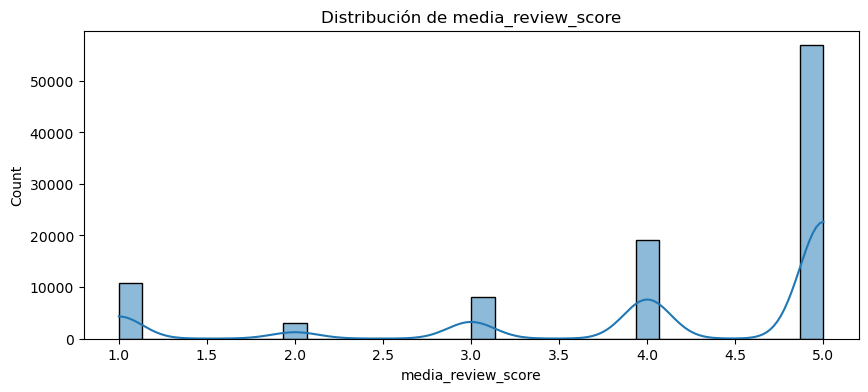

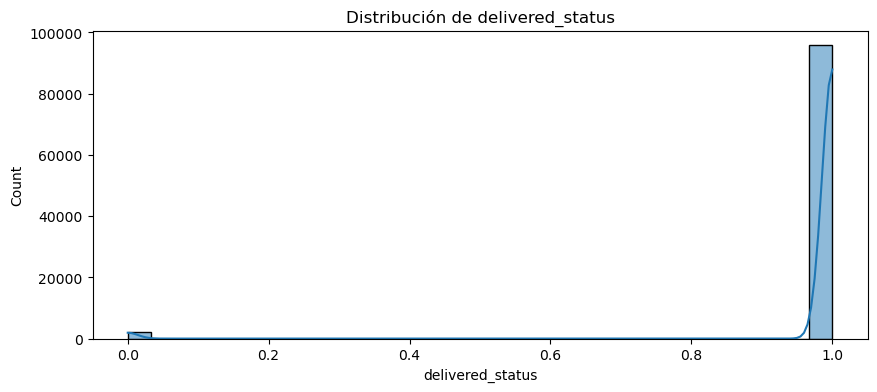

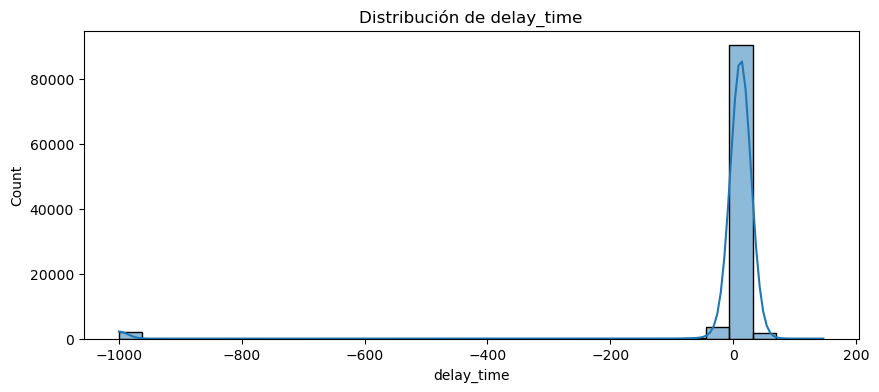

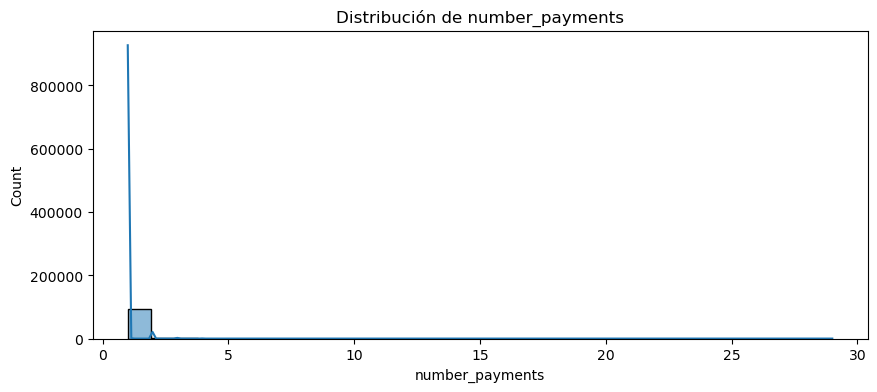

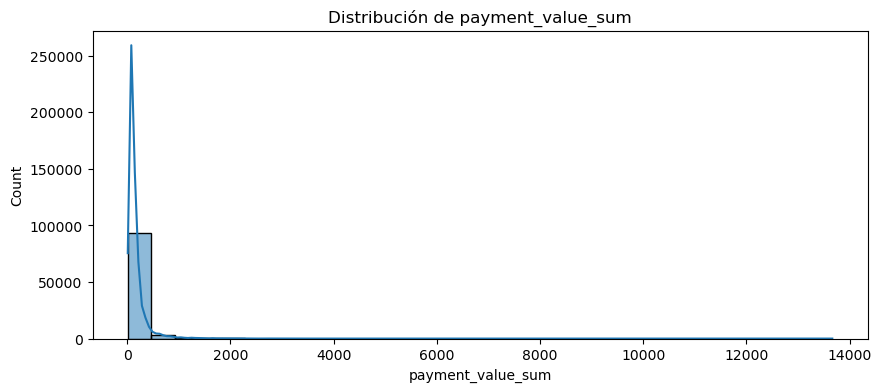

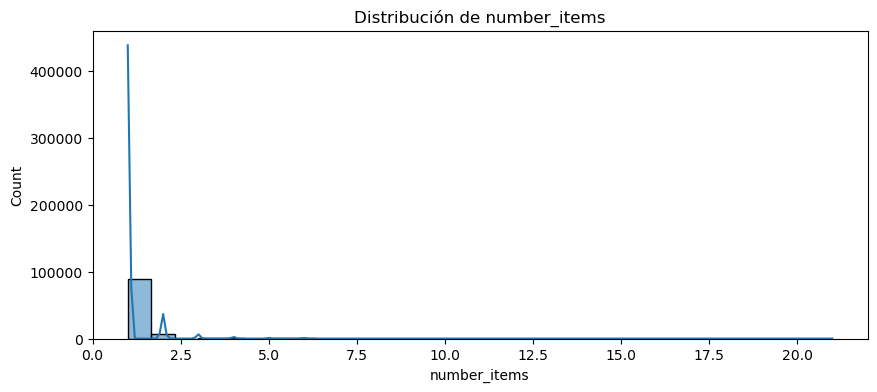

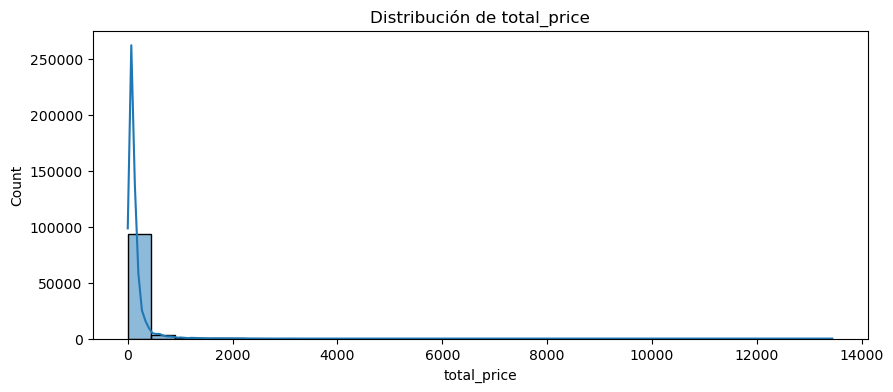

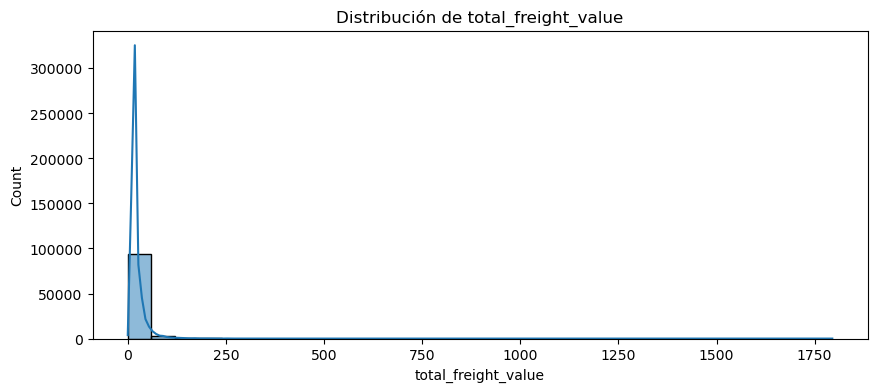

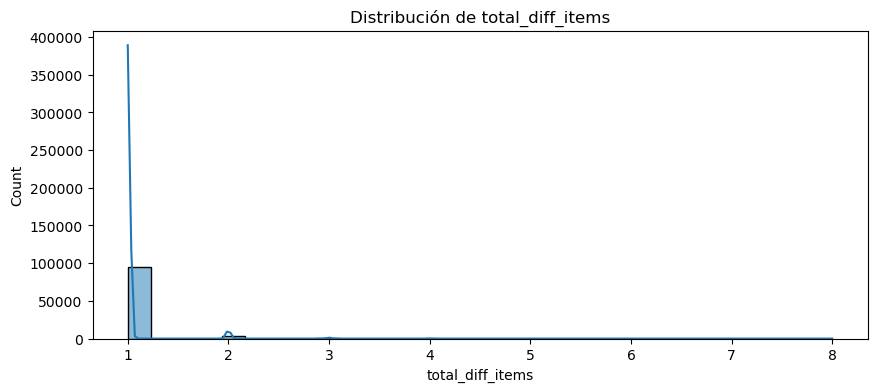

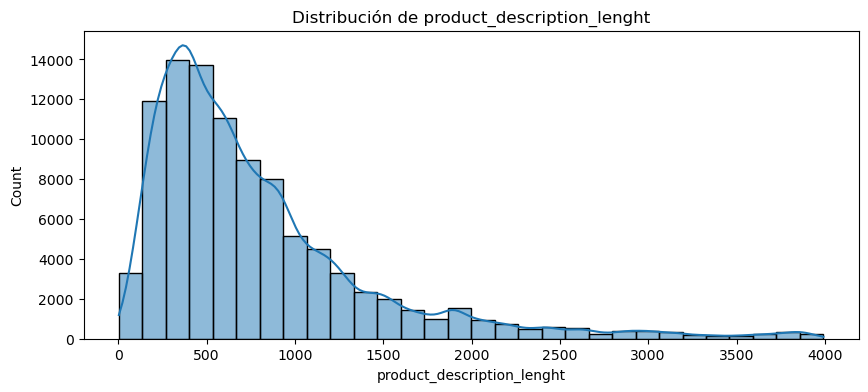

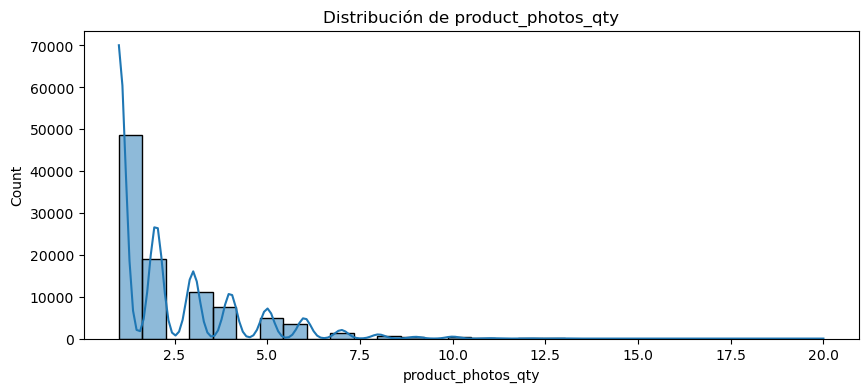

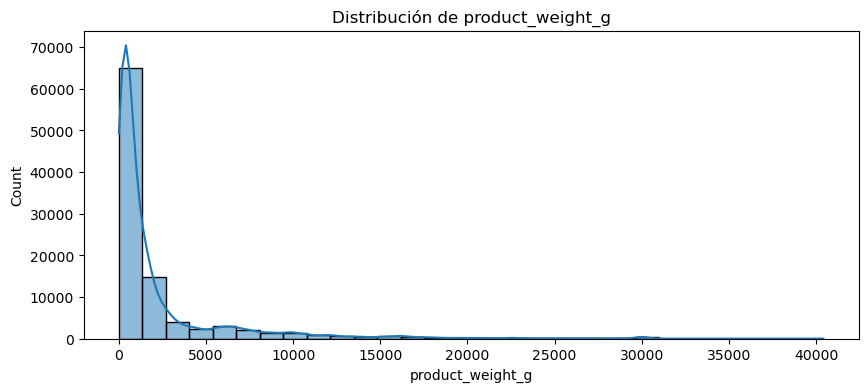

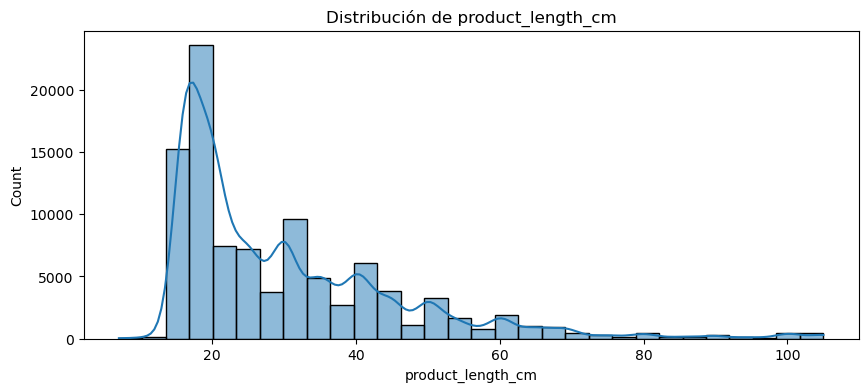

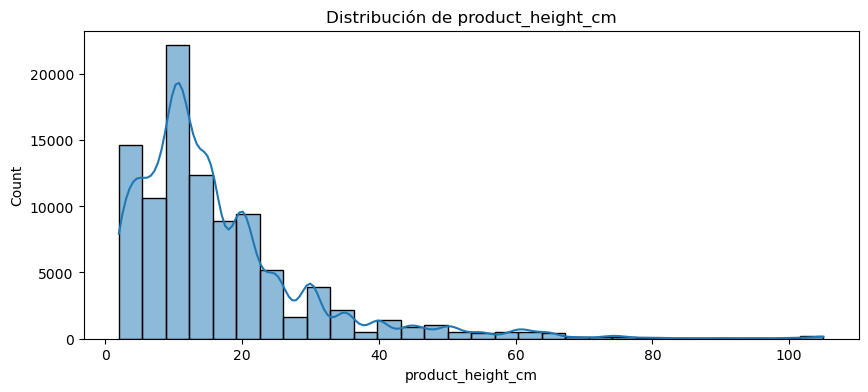

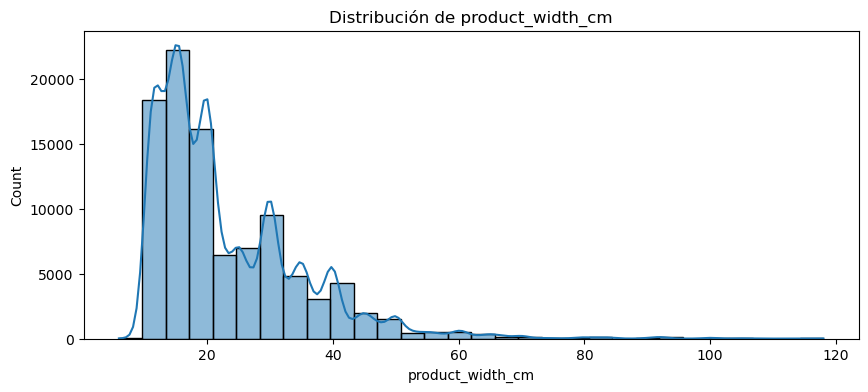

In [8]:
numericas = ['media_review_score', 'delivered_status','delay_time', 'number_payments', 'payment_value_sum',
             'number_items', 'total_price', 'total_freight_value', 'total_diff_items',
             'product_description_lenght', 'product_photos_qty', 'product_weight_g',
             'product_length_cm', 'product_height_cm', 'product_width_cm']

for col in numericas:
    plt.figure(figsize=(10,4))
    sns.histplot(data[col], kde=True, bins=30)
    plt.title(f'Distribución de {col}')
    plt.show()

### 4.1.2 Variables numéricas discretas

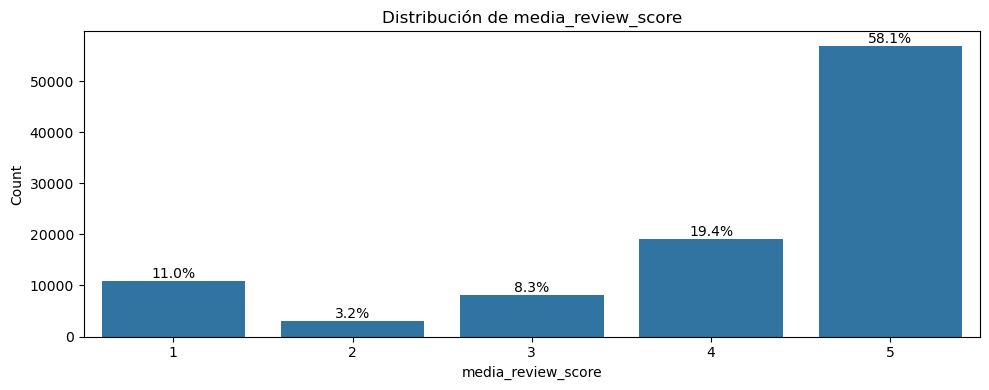

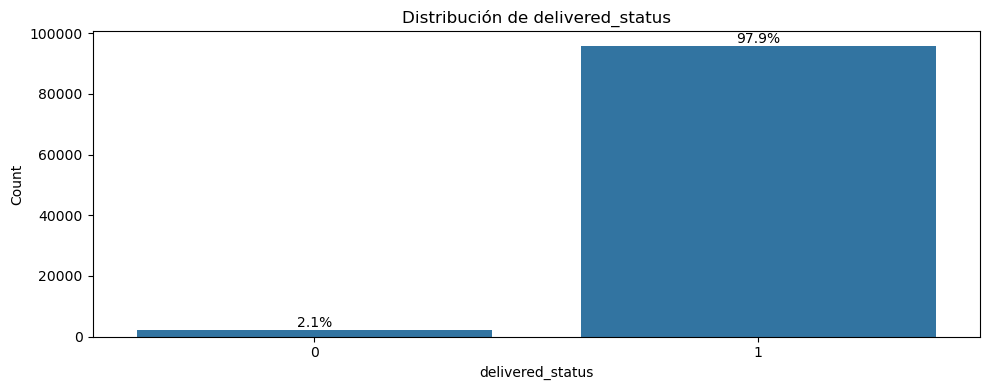

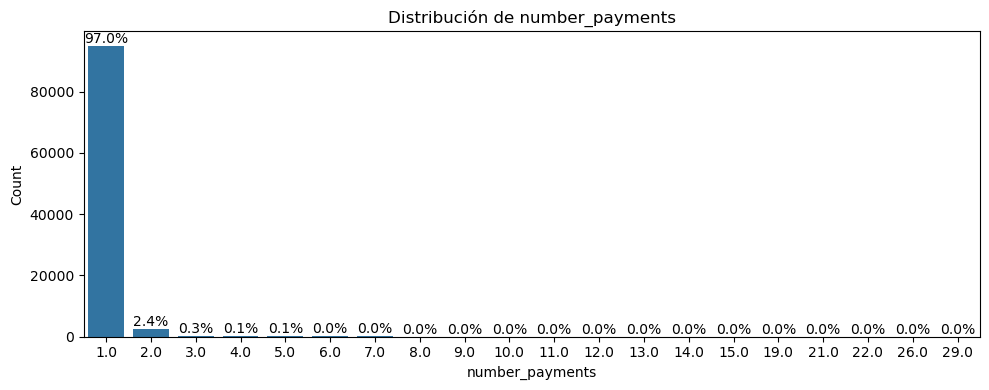

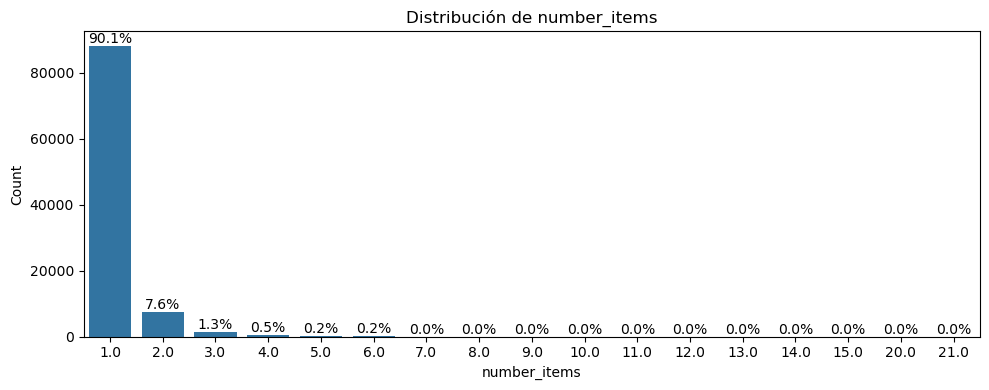

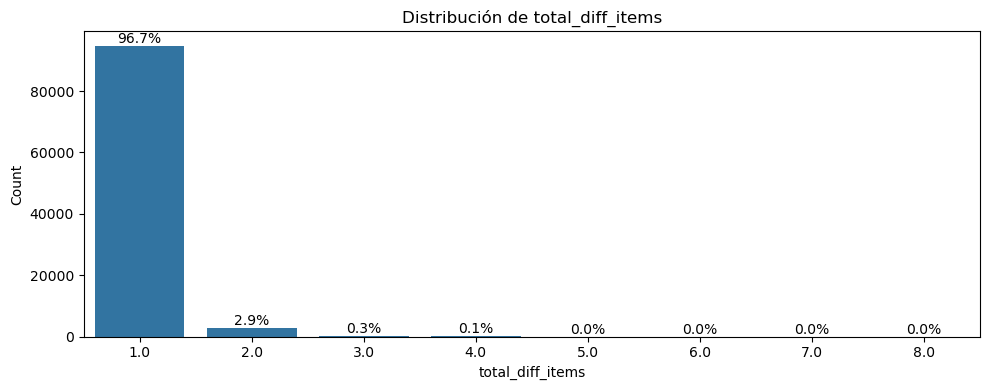

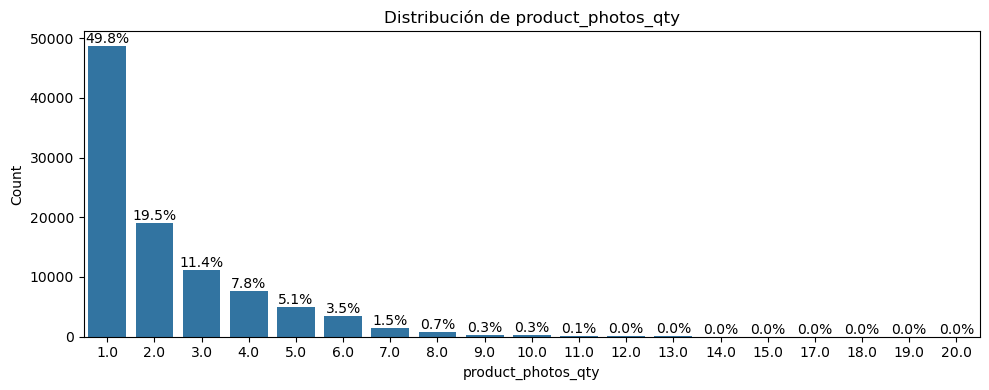

In [9]:
numericas_disc = ['media_review_score', 'delivered_status','number_payments',
                  'number_items', 'total_diff_items', 'product_photos_qty']

for col in numericas_disc:
    plt.figure(figsize=(10, 4))

    ax = sns.countplot(x=col,data=data)

    # Total de observaciones
    total = len(data[col])

    # Añadir porcentajes encima de cada barra
    for p in ax.patches:
        count = p.get_height()
        percentage = 100 * count / total
        ax.annotate(
            f'{percentage:.1f}%',
            (p.get_x() + p.get_width() / 2., count),
            ha='center',
            va='bottom',
            fontsize=10
        )

    plt.title(f'Distribución de {col}')
    plt.ylabel('Count')
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

In [10]:
# Agrupaciones para las que están muy sesgadas:
data['product_photos_qty_grouped'] = data['product_photos_qty'].where(
    data['product_photos_qty'].isin([1, 2, 3, 4, 5]),
    'Others')

### 4.2 Variables categóricas

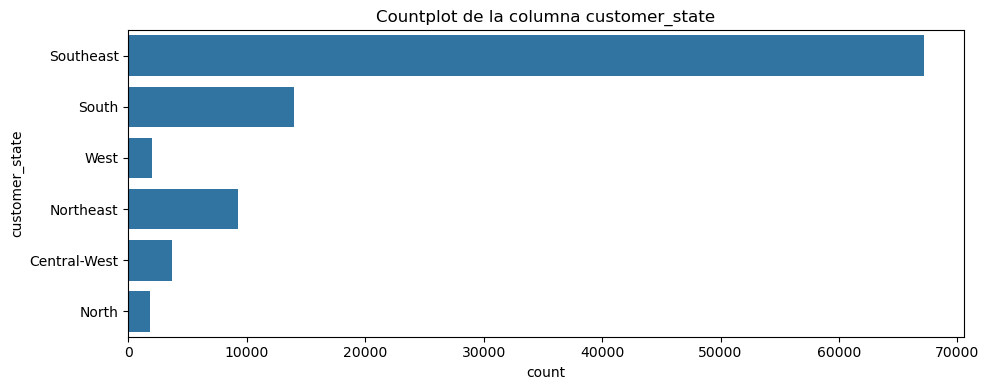

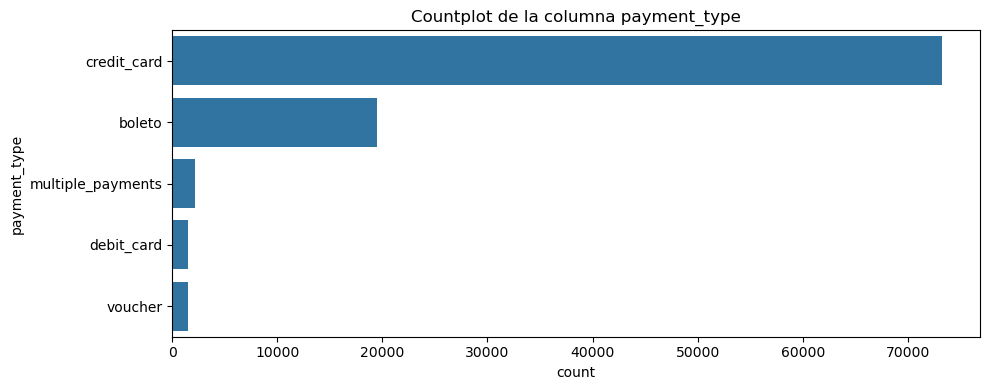

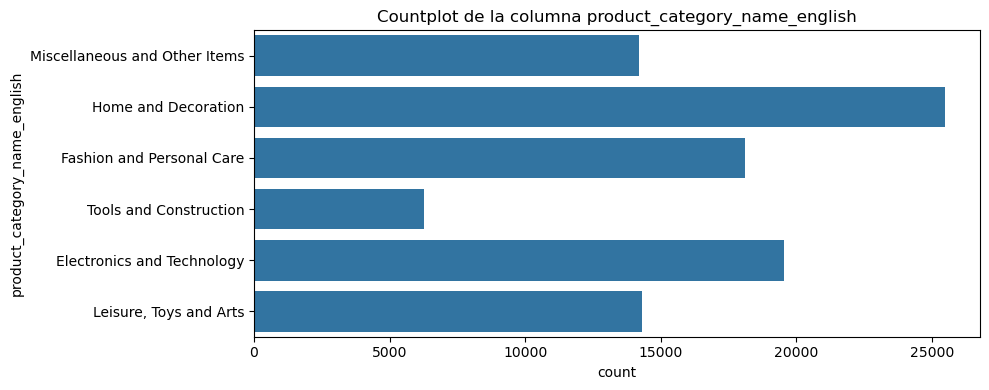

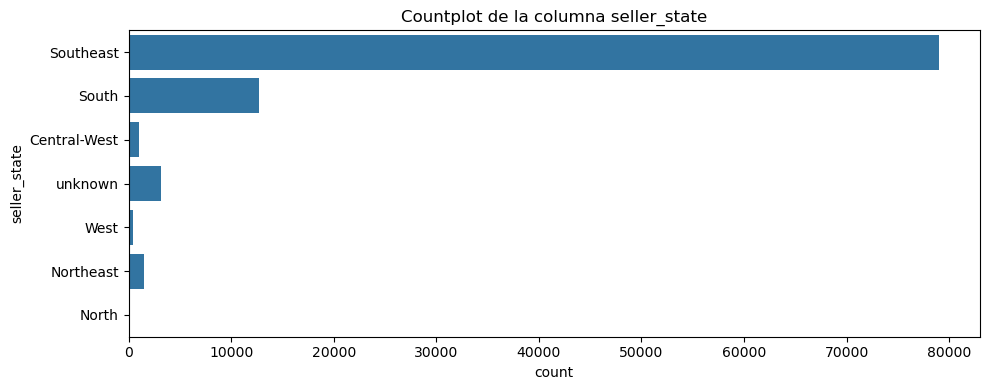

In [11]:
categoricas = ['customer_state', 'payment_type', 'product_category_name_english', 'seller_state']

for col in categoricas:
    plt.figure(figsize=(10,4))   # mismo ancho y alto para todos
    sns.countplot(data=data, y=col)
    plt.title(f'Countplot de la columna {col}')
    plt.tight_layout()            # evita que se corte el texto
    plt.show()

In [12]:
# Agrupaciones:
data['customer_state_grouped'] = np.where(data['customer_state'] == 'Southeast','Southeast', 'Others')
data['seller_state_grouped'] = np.where(data['seller_state'] == 'Southeast','Southeast', 'Others')
data['payment_type_grouped'] = np.where(data['payment_type'] == 'credit_card','credit_card', 'Others')

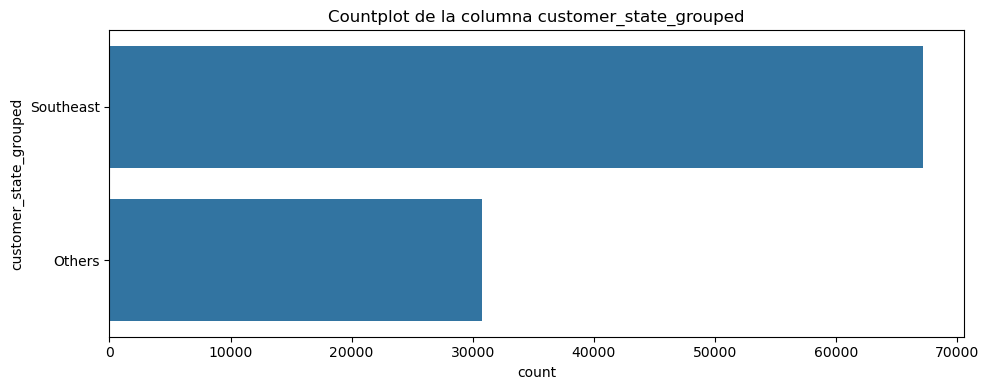

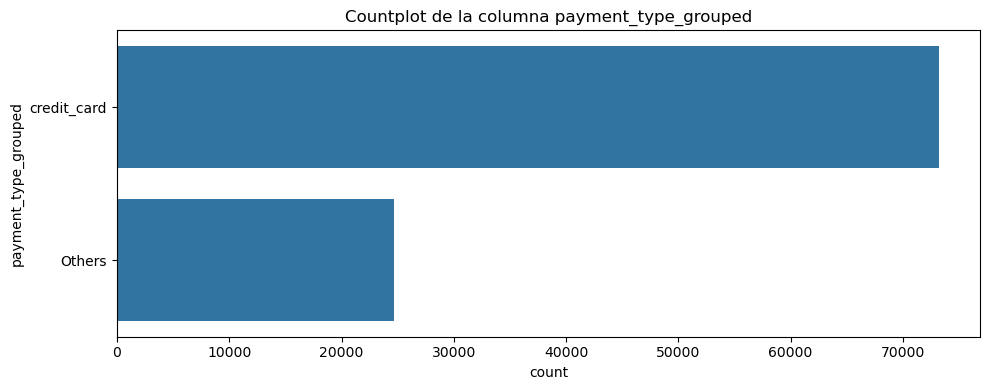

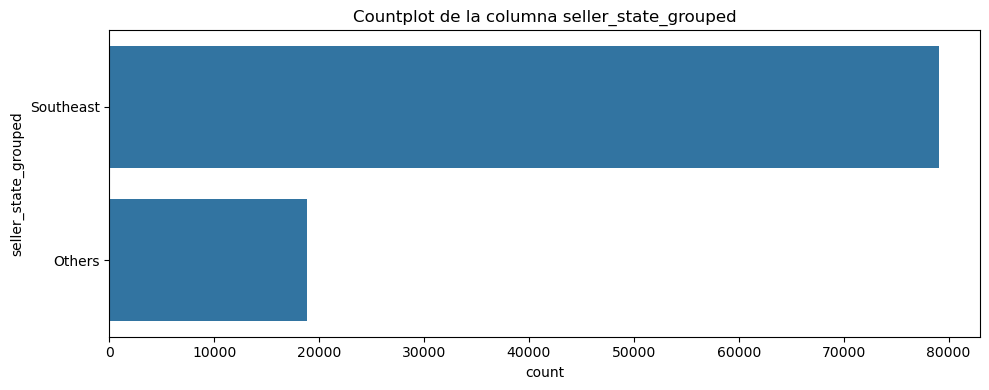

In [13]:
categoricas_agrupadas = ['customer_state_grouped', 'payment_type_grouped', 'seller_state_grouped']

for col in categoricas_agrupadas:
    plt.figure(figsize=(10,4))   # mismo ancho y alto para todos
    sns.countplot(data=data, y=col)
    plt.title(f'Countplot de la columna {col}')
    plt.tight_layout()            # evita que se corte el texto
    plt.show()

### 4.4 Top N vendedores 80%:

In [14]:
ventas_por_vendedor = (
    data.groupby('seller_id')['total_price']
    .sum()
    .sort_values(ascending=False)
)

C:\Users\usuario\AppData\Local\Temp\ipykernel_18844\3981642647.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top20_vendedores.values, y=top20_vendedores.index, palette='viridis')


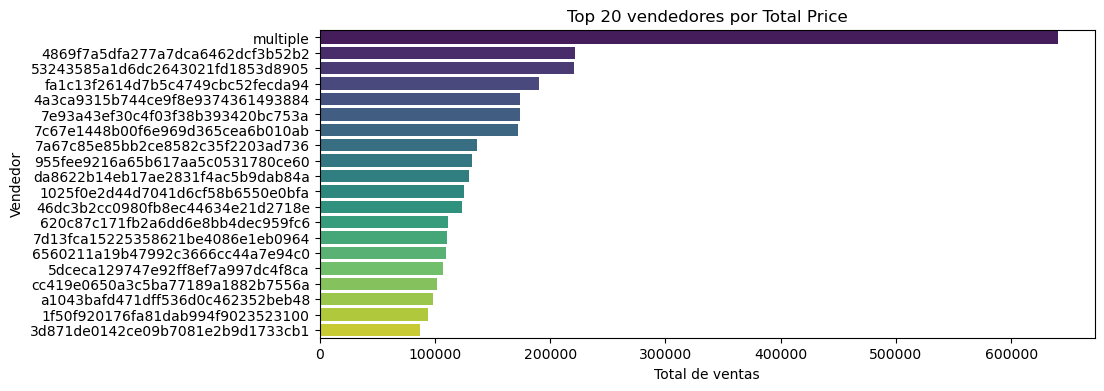

In [15]:
#influencia del valor 'multiple' ¿outlier? Sí
top20_vendedores = ventas_por_vendedor.head(20)

plt.figure(figsize=(10,4))
sns.barplot(x=top20_vendedores.values, y=top20_vendedores.index, palette='viridis')
plt.title('Top 20 vendedores por Total Price')
plt.xlabel('Total de ventas')
plt.ylabel('Vendedor')
plt.show()

In [16]:
ventas_acumuladas = ventas_por_vendedor.cumsum()
porcentaje_acumulado = ventas_acumuladas / ventas_por_vendedor.sum()

In [17]:
#Menos del 20% de vendedores explican el 80% de las ventas
num_vendedores_80 = (porcentaje_acumulado <= 0.80).sum()
num_vendedores_80

np.int64(517)

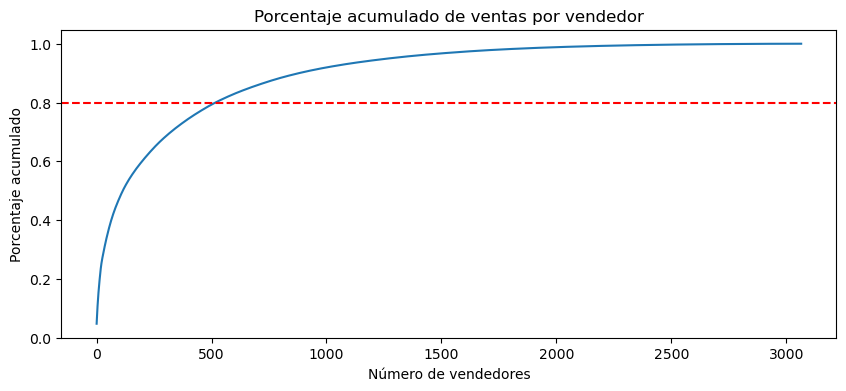

In [18]:
plt.figure(figsize=(10,4))
plt.plot(porcentaje_acumulado.values)
plt.axhline(0.80, color='red', linestyle='--')
plt.title('Porcentaje acumulado de ventas por vendedor')
plt.xlabel('Número de vendedores')
plt.ylabel('Porcentaje acumulado')
plt.show()

### 4.5 Top N productos 80%:

In [19]:
ventas_por_producto = (
    data.groupby('product_id')['total_price']
    .sum()
    .sort_values(ascending=False)
)

C:\Users\usuario\AppData\Local\Temp\ipykernel_18844\2466291929.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top20_productos.values, y=top20_productos.index, palette='magma')


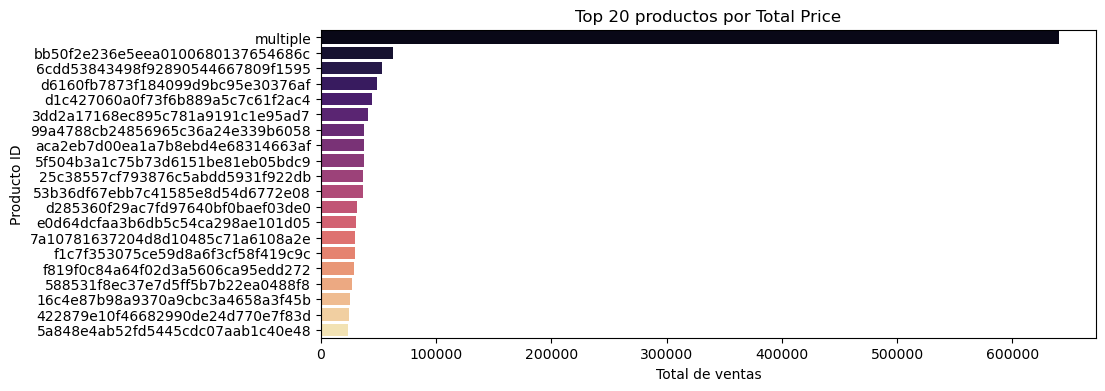

In [20]:
#influencia del valor 'multiple' ¿outlier? Sí
top20_productos = ventas_por_producto.head(20)

plt.figure(figsize=(10,4))
sns.barplot(x=top20_productos.values, y=top20_productos.index, palette='magma')
plt.title('Top 20 productos por Total Price')
plt.xlabel('Total de ventas')
plt.ylabel('Producto ID')
plt.show()

In [21]:
ventas_acumuladas_prod = ventas_por_producto.cumsum()
porcentaje_acumulado_prod = ventas_acumuladas_prod / ventas_por_producto.sum()

In [22]:
#Menos del 30% de productos explican el 80% de las ventas
num_productos_80 = (porcentaje_acumulado_prod <= 0.80).sum()
num_productos_80

np.int64(7645)

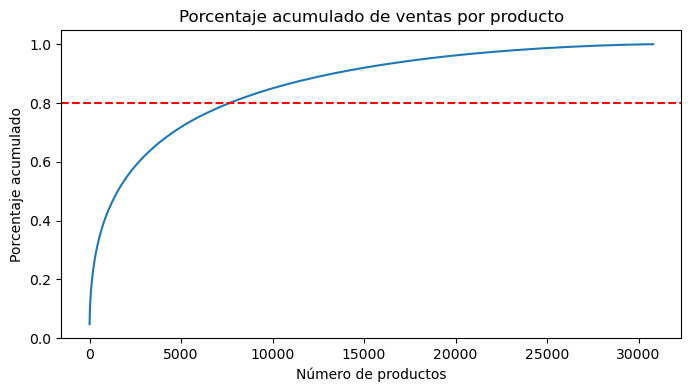

In [23]:
plt.figure(figsize=(8,4))
plt.plot(porcentaje_acumulado_prod.values)
plt.axhline(0.80, color='red', linestyle='--')
plt.title('Porcentaje acumulado de ventas por producto')
plt.xlabel('Número de productos')
plt.ylabel('Porcentaje acumulado')
plt.show()

## 5. OUTLIERS HAY MUCHOS y son muy importantes para KNN porque este modelo usa distancias

In [24]:
num_multiple = (data['seller_id'] == 'multiple').sum()
print(f"Filas con seller_id = 'multiple': {num_multiple}")

Filas con seller_id = 'multiple': 3197


In [25]:
num_multiple2 = (data['product_id'] == 'multiple').sum()
print(f"Filas con product_id = 'multiple': {num_multiple2}")

Filas con product_id = 'multiple': 3197


In [26]:
#Ver si son las mismas filas y que suponen un 3% de las observaciones
filtro = (data['seller_id'] == 'multiple') | (data['product_id'] == 'multiple')

num_filas_multiple = filtro.sum()
num_filas_multiple

np.int64(3197)

In [27]:
#Elimino las observaciones:
data = data[(data['seller_id'] != 'multiple') & (data['product_id'] != 'multiple')]
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 94719 entries, 0 to 97915
Data columns (total 30 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Unnamed: 0                     94719 non-null  int64  
 1   order_id                       94719 non-null  object 
 2   media_review_score             94719 non-null  int64  
 3   fecha_ultima_review            94719 non-null  object 
 4   order_purchase_timestamp       94719 non-null  object 
 5   delivered_status               94719 non-null  int64  
 6   delay_time                     94719 non-null  int64  
 7   customer_unique_id             94719 non-null  object 
 8   customer_state                 94719 non-null  object 
 9   number_payments                94719 non-null  float64
 10  payment_value_sum              94719 non-null  float64
 11  payment_type                   94719 non-null  object 
 12  number_items                   94719 non-null  floa

### Compruebo con gráfico VENDEDORES DE NUEVO

C:\Users\usuario\AppData\Local\Temp\ipykernel_18844\3372710881.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top20_vendedores.values, y=top20_vendedores.index, palette='viridis')


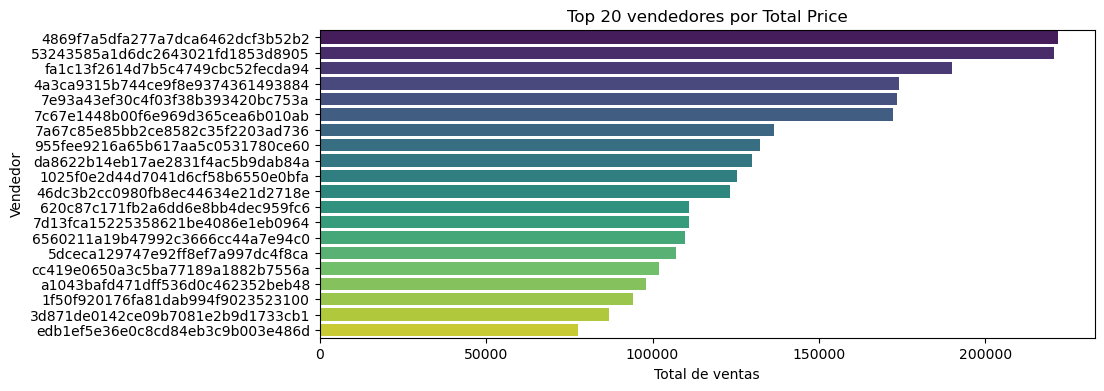

In [28]:
ventas_por_vendedor = (
    data.groupby('seller_id')['total_price']
    .sum()
    .sort_values(ascending=False)
)
top20_vendedores = ventas_por_vendedor.head(20)

plt.figure(figsize=(10,4))
sns.barplot(x=top20_vendedores.values, y=top20_vendedores.index, palette='viridis')
plt.title('Top 20 vendedores por Total Price')
plt.xlabel('Total de ventas')
plt.ylabel('Vendedor')
plt.show()

### GRÁFICAS con bigote para ver las desviaciones fuera del rango

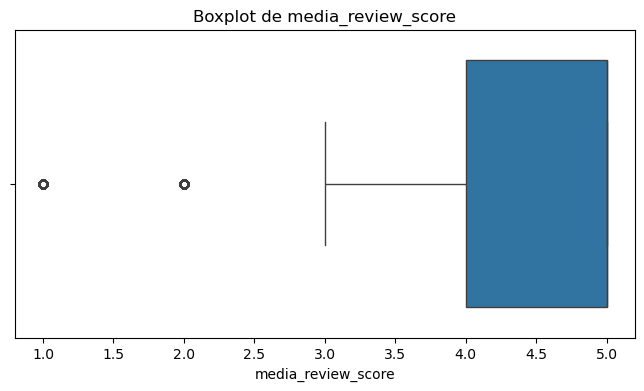

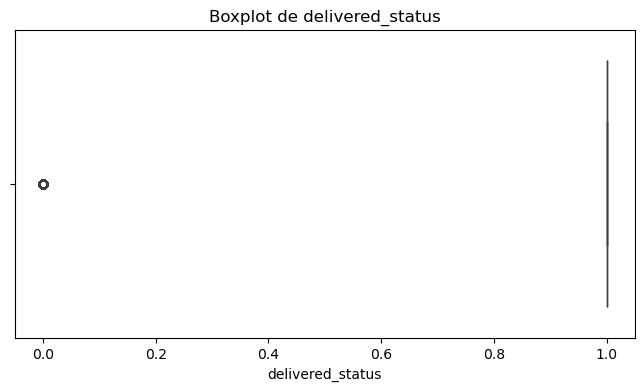

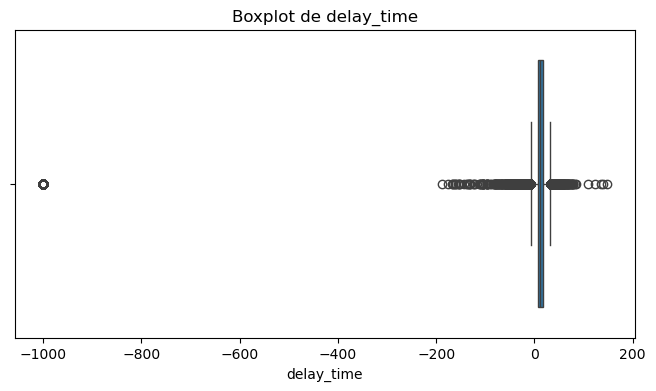

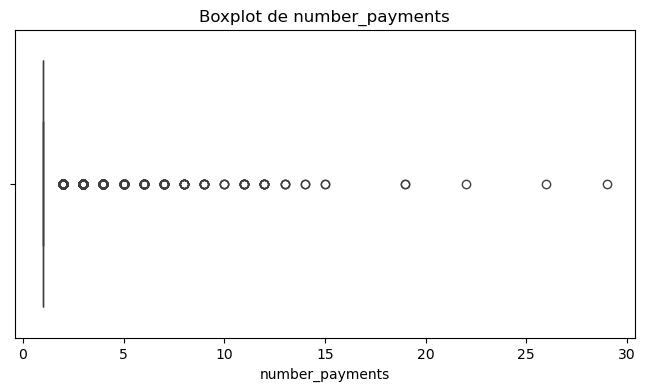

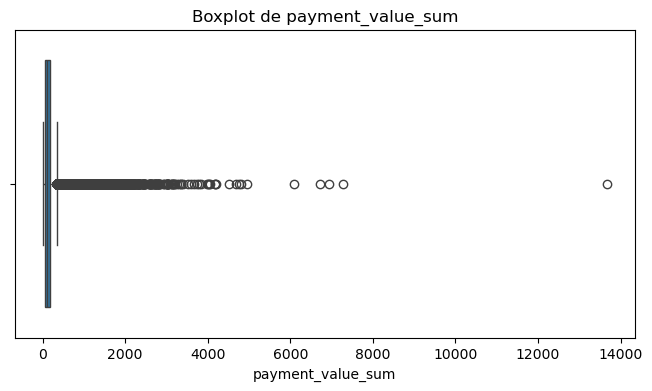

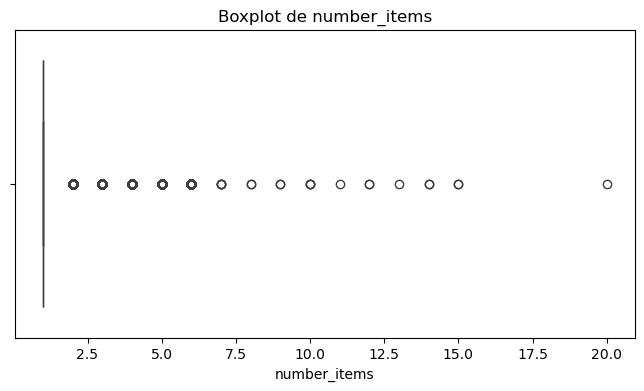

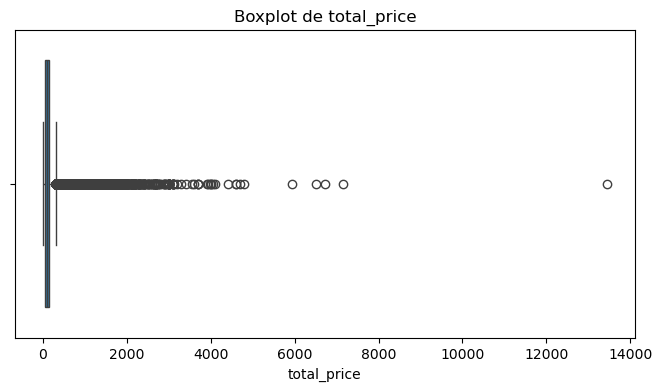

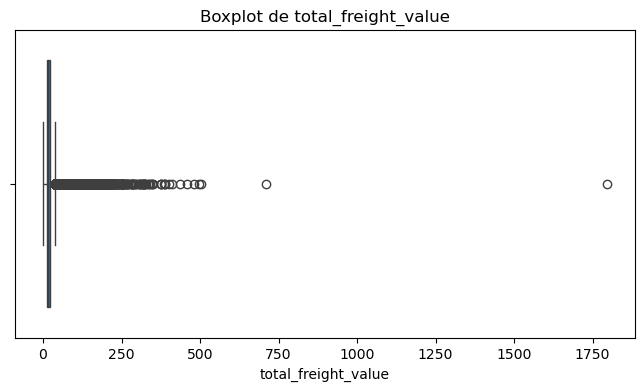

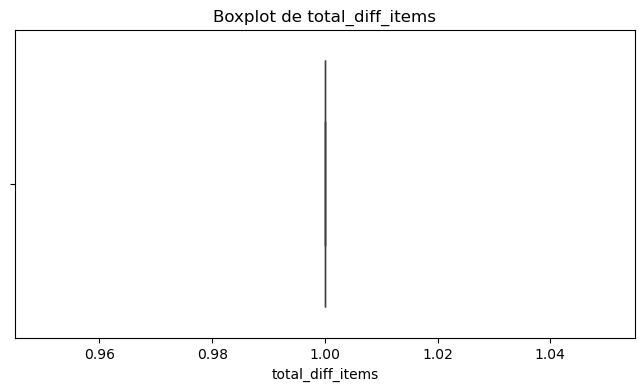

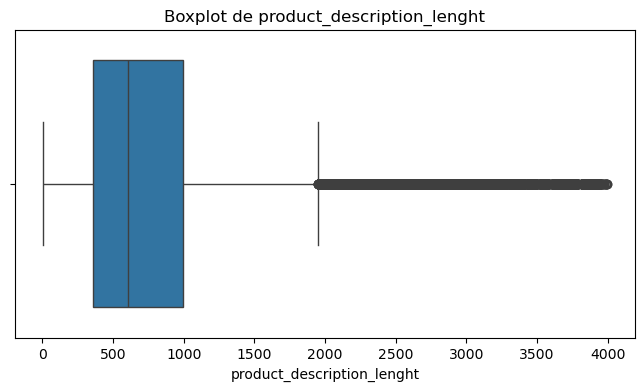

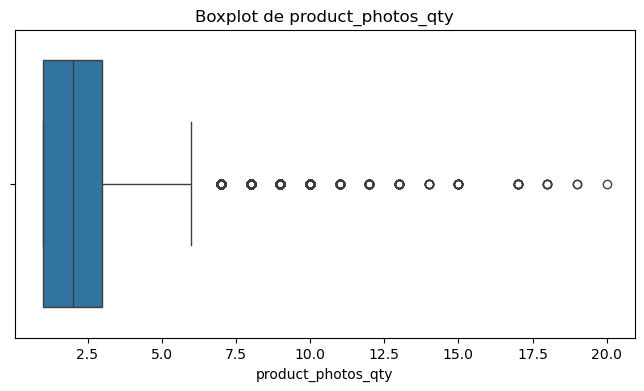

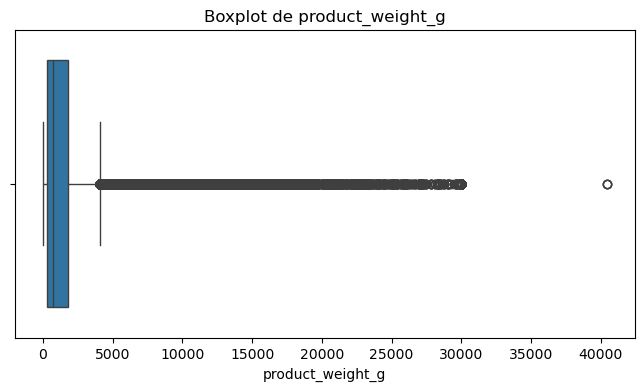

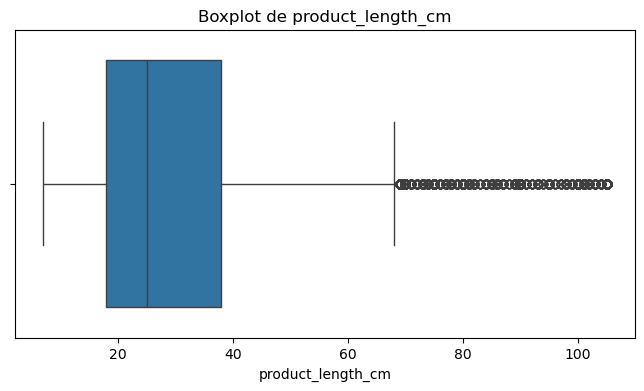

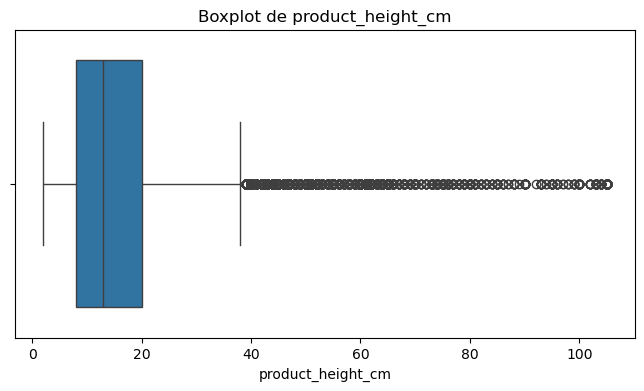

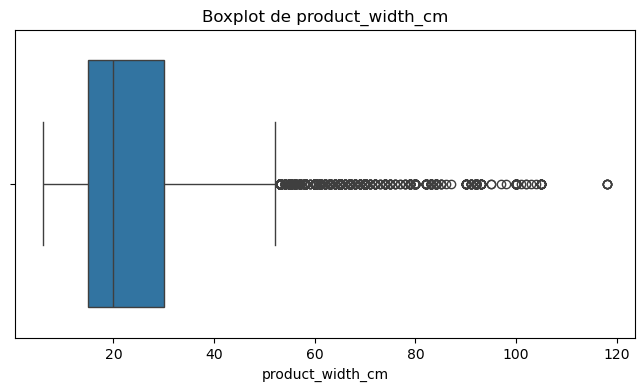

In [29]:
for col in numericas:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=data[col])
    plt.title(f'Boxplot de {col}')
    plt.show()

In [30]:
columna = 'delay_time'

# Medidas básicas
media = data[columna].mean()
mediana = data[columna].median()
moda = data[columna].mode()

print("Media:", media)
print("Mediana:", mediana)
print("Moda:", moda)
print("Mínimo:", data[columna].min())
print("Máximo:", data[columna].max())
print(data[columna].quantile([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))

# Detección de outliers con IQR
Q1 = data[columna].quantile(0.25)
Q3 = data[columna].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print("Límite inferior:", limite_inferior)
print("Límite superior:", limite_superior)

#outliers = ((data[columna] < limite_inferior) | (data[columna] > limite_superior)).sum()
outliers = ((data[columna] == -1000)).sum()
print(f"Número de outliers en {columna}: {outliers}")

Media: -10.07244586619369
Mediana: 12.0
Moda: 0    14
Name: delay_time, dtype: int64
Mínimo: -1000
Máximo: 147
0.01   -1000.0
0.05      -8.0
0.25       7.0
0.50      12.0
0.75      17.0
0.95      26.0
0.99      35.0
Name: delay_time, dtype: float64
Límite inferior: -8.0
Límite superior: 32.0
Número de outliers en delay_time: 2050


In [31]:
columna = 'payment_value_sum'

# Medidas básicas
media = data[columna].mean()
mediana = data[columna].median()
moda = data[columna].mode()

print("Media:", media)
print("Mediana:", mediana)
print("Moda:", moda)
print("Mínimo:", data[columna].min())
print("Máximo:", data[columna].max())
print(data[columna].quantile([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))

# Detección de outliers con IQR
Q1 = data[columna].quantile(0.25)
Q3 = data[columna].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print("Límite inferior:", limite_inferior)
print("Límite superior:", limite_superior)

outliers = ((data[columna] < limite_inferior) | (data[columna] > limite_superior)).sum()
#outliers = ((data[columna] >5000)).sum()
print(f"Número de outliers en {columna}: {outliers}")

# Eliminación de outliers
data = data[
    (data[columna] >= limite_inferior) &
    (data[columna] <= limite_superior)
]

print(f"Filas tras eliminar outliers: {data.shape[0]}")

Media: 157.52914293858674
Mediana: 103.04
Moda: 0    77.57
Name: payment_value_sum, dtype: float64
Mínimo: 9.59
Máximo: 13664.08
0.01      22.360
0.05      32.190
0.25      60.865
0.50     103.040
0.75     173.090
0.95     440.190
0.99    1053.515
Name: payment_value_sum, dtype: float64
Límite inferior: -107.47250000000001
Límite superior: 341.4275
Número de outliers en payment_value_sum: 7444
Filas tras eliminar outliers: 87275


In [32]:
columna = 'total_price'

# Medidas básicas
media = data[columna].mean()
mediana = data[columna].median()
moda = data[columna].mode()

print("Media:", media)
print("Mediana:", mediana)
print("Moda:", moda)
print("Mínimo:", data[columna].min())
print("Máximo:", data[columna].max())
print(data[columna].quantile([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))

# Detección de outliers con IQR
Q1 = data[columna].quantile(0.25)
Q3 = data[columna].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print("Límite inferior:", limite_inferior)
print("Límite superior:", limite_superior)

outliers = ((data[columna] < limite_inferior) | (data[columna] > limite_superior)).sum()
#outliers = ((data[columna]>5000)|(data[columna]<0)).sum()
print(f"Número de outliers en {columna}: {outliers}")

# Eliminación de outliers
data = data[
    (data[columna] >= limite_inferior) &
    (data[columna] <= limite_superior)
]

print(f"Filas tras eliminar outliers: {data.shape[0]}")


Media: 93.00801787453453
Mediana: 77.69999999999999
Moda: 0    59.9
Name: total_price, dtype: float64
Mínimo: 0.85
Máximo: 330.0
0.01     11.55
0.05     18.90
0.25     41.90
0.50     77.70
0.75    129.00
0.95    229.00
0.99    298.00
Name: total_price, dtype: float64
Límite inferior: -88.74999999999997
Límite superior: 259.65
Número de outliers en total_price: 2356
Filas tras eliminar outliers: 84919


In [33]:
columna = 'total_freight_value'

# Medidas básicas
media = data[columna].mean()
mediana = data[columna].median()
moda = data[columna].mode()

print("Media:", media)
print("Mediana:", mediana)
print("Moda:", moda)
print("Mínimo:", data[columna].min())
print("Máximo:", data[columna].max())
print(data[columna].quantile([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))

# Detección de outliers con IQR
Q1 = data[columna].quantile(0.25)
Q3 = data[columna].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print("Límite inferior:", limite_inferior)
print("Límite superior:", limite_superior)

outliers = ((data[columna] < limite_inferior) | (data[columna] > limite_superior)).sum()
#outliers = ((data[columna] > 1000)).sum()
print(f"Número de outliers en {columna}: {outliers}")

# Eliminación de outliers
data = data[
    (data[columna] >= limite_inferior) &
    (data[columna] <= limite_superior)
]

print(f"Filas tras eliminar outliers: {data.shape[0]}")

Media: 19.630631071962693
Mediana: 16.32
Moda: 0    15.1
Name: total_freight_value, dtype: float64
Mínimo: 0.0
Máximo: 215.43
0.01     7.39
0.05     7.78
0.25    13.37
0.50    16.32
0.75    21.40
0.95    43.42
0.99    70.40
Name: total_freight_value, dtype: float64
Límite inferior: 1.325000000000001
Límite superior: 33.44499999999999
Número de outliers en total_freight_value: 9042
Filas tras eliminar outliers: 75877


In [34]:
filtro = (
    (data['delay_time'] == -1000))

# Contar cuántas filas cumplen al menos una condición
num_observaciones = filtro.sum()
num_observaciones

np.int64(1533)

In [35]:
data = data[~filtro]
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 74344 entries, 0 to 97915
Data columns (total 30 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Unnamed: 0                     74344 non-null  int64  
 1   order_id                       74344 non-null  object 
 2   media_review_score             74344 non-null  int64  
 3   fecha_ultima_review            74344 non-null  object 
 4   order_purchase_timestamp       74344 non-null  object 
 5   delivered_status               74344 non-null  int64  
 6   delay_time                     74344 non-null  int64  
 7   customer_unique_id             74344 non-null  object 
 8   customer_state                 74344 non-null  object 
 9   number_payments                74344 non-null  float64
 10  payment_value_sum              74344 non-null  float64
 11  payment_type                   74344 non-null  object 
 12  number_items                   74344 non-null  floa

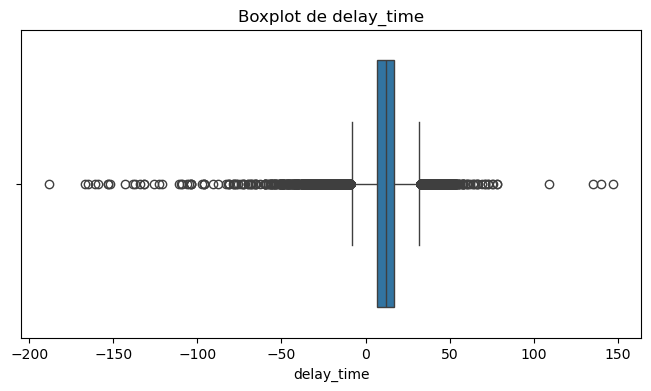

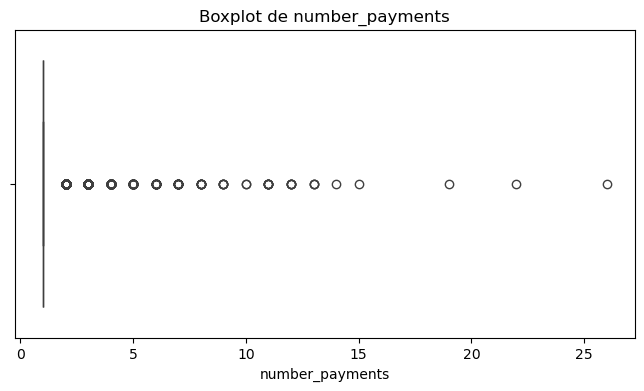

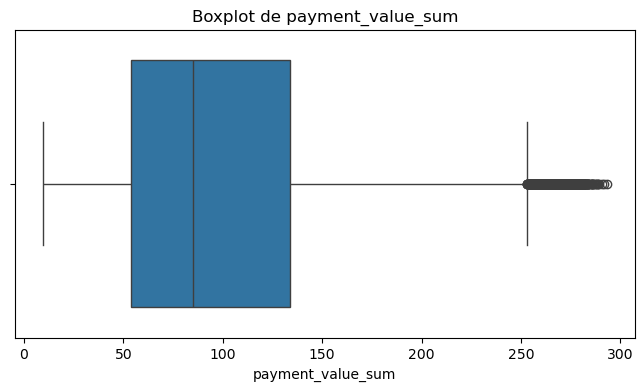

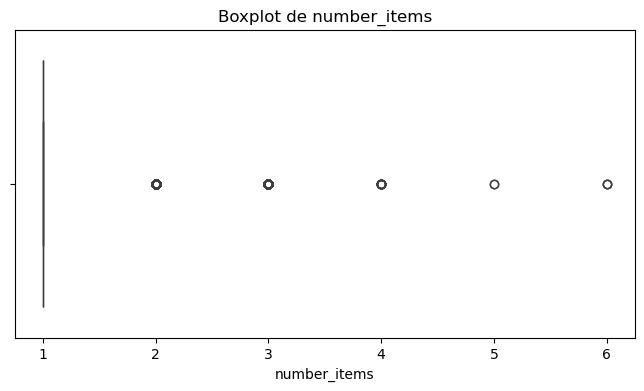

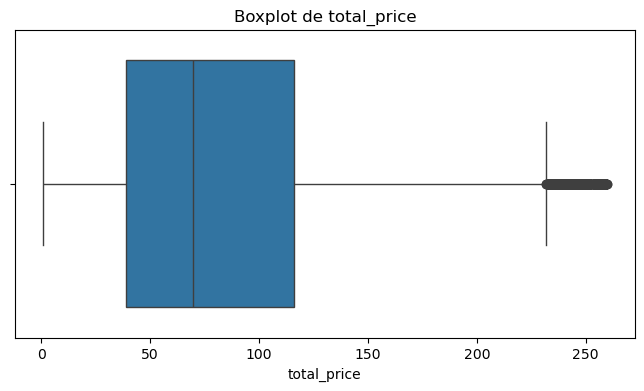

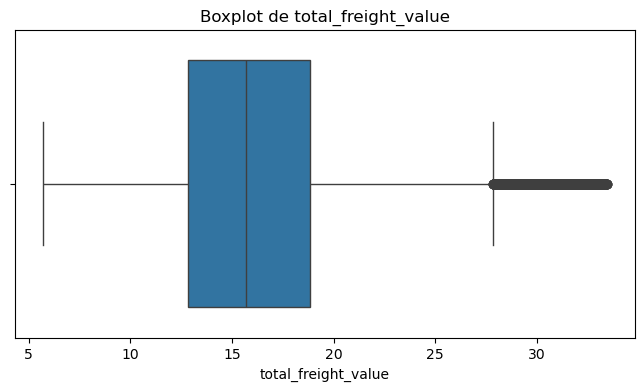

In [36]:
num_SIN_out = ['delay_time', 'number_payments', 'payment_value_sum',
             'number_items', 'total_price', 'total_freight_value']

for col in num_SIN_out:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=data[col])
    plt.title(f'Boxplot de {col}')
    plt.show()

## 6. Nuevas columnas

In [37]:
data['y_satisfecho'] = (data['media_review_score'] == 5).astype(int)
data['y_satisfecho'].value_counts()

y_satisfecho
1    44986
0    29358
Name: count, dtype: int64

In [38]:
data[['media_review_score', 'y_satisfecho']].head()

,media_review_score,y_satisfecho
0,5,1
1,4,0
2,5,1
3,4,0
4,5,1


In [39]:
topN_vendedores = ventas_por_vendedor.head(num_vendedores_80).index
data['seller_topN'] = data['seller_id'].isin(topN_vendedores).astype(int)

In [40]:
topN_productos = ventas_por_producto.head(num_productos_80).index
data['product_topN'] = data['product_id'].isin(topN_productos).astype(int)

In [41]:
data[['seller_topN', 'product_topN']].nunique()

seller_topN     2
product_topN    2
dtype: int64

## 7. Eliminar columnas

- Unnamed:0. Es el número de fila
- fechas, las he descompuesto
- id's. KNN se basa en distancias y estos valores únicos crean ruido
- datos desbalanceados, states y payment_type, agrupados
- media_reiew_score, convertida a y_satisfecho

In [42]:
#hecho
data = data.drop(columns=['Unnamed: 0'])

In [43]:
columnas_eliminar = [
    'order_id', 'customer_unique_id', 'product_id', 
    'seller_id','fecha_ultima_review', 'order_purchase_timestamp',
    'media_review_score','seller_state','customer_state','payment_type',
    'product_photos_qty', 'delivered_status', 'number_payments',
    'number_items', 'total_diff_items', 'fecha_ultima_review', 
    'order_purchase_timestamp'
]
data.drop(columns=columnas_eliminar, inplace=True)

In [44]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 74344 entries, 0 to 97915
Data columns (total 17 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   delay_time                     74344 non-null  int64  
 1   payment_value_sum              74344 non-null  float64
 2   total_price                    74344 non-null  float64
 3   total_freight_value            74344 non-null  float64
 4   product_description_lenght     74344 non-null  float64
 5   product_weight_g               74344 non-null  float64
 6   product_length_cm              74344 non-null  float64
 7   product_height_cm              74344 non-null  float64
 8   product_width_cm               74344 non-null  float64
 9   product_category_name_english  74344 non-null  object 
 10  product_photos_qty_grouped     74344 non-null  object 
 11  customer_state_grouped         74344 non-null  object 
 12  seller_state_grouped           74344 non-null  obje

## 8. Dummies

In [45]:
data = pd.get_dummies(
    data, 
    columns=['product_category_name_english','customer_state_grouped',
             'seller_state_grouped','payment_type_grouped',
              'product_photos_qty_grouped'],
    drop_first = True
)

In [46]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 74344 entries, 0 to 97915
Data columns (total 25 columns):
 #   Column                                                       Non-Null Count  Dtype  
---  ------                                                       --------------  -----  
 0   delay_time                                                   74344 non-null  int64  
 1   payment_value_sum                                            74344 non-null  float64
 2   total_price                                                  74344 non-null  float64
 3   total_freight_value                                          74344 non-null  float64
 4   product_description_lenght                                   74344 non-null  float64
 5   product_weight_g                                             74344 non-null  float64
 6   product_length_cm                                            74344 non-null  float64
 7   product_height_cm                                            74344 non-null  floa

## 9. Normalización

In [47]:
numericas = data.select_dtypes(include=['float64', 'int64','int32']).columns
data[numericas] = (data[numericas] - data[numericas].min()) / (data[numericas].max() - data[numericas].min())

In [48]:
data.head(10)

,delay_time,payment_value_sum,total_price,total_freight_value,product_description_lenght,product_weight_g,product_length_cm,product_height_cm,product_width_cm,y_satisfecho,...,product_category_name_english_Miscellaneous and Other Items,product_category_name_english_Tools and Construction,customer_state_grouped_Southeast,seller_state_grouped_Southeast,payment_type_grouped_credit_card,product_photos_qty_grouped_2.0,product_photos_qty_grouped_3.0,product_photos_qty_grouped_4.0,product_photos_qty_grouped_5.0,product_photos_qty_grouped_Others
0,0.588060,0.220827,0.224348,0.273711,0.149209,0.016079,0.214286,0.067961,0.071429,1.0,...,True,False,True,True,True,False,False,True,False,False
1,0.570149,0.882743,0.923865,0.513163,0.059030,0.742115,0.438776,0.271845,0.303571,0.0,...,True,False,True,True,True,True,False,False,False,False
2,0.602985,0.731198,0.765797,0.438875,0.173574,0.075448,0.265306,0.106796,0.241071,1.0,...,False,False,True,True,True,True,False,False,False,False
3,0.579104,0.057112,0.046918,0.255680,0.119568,0.004947,0.091837,0.077670,0.080357,0.0,...,False,False,True,True,True,False,False,False,False,False
4,0.608955,0.735325,0.769275,0.448612,0.101733,0.092764,0.285714,0.368932,0.214286,1.0,...,False,True,True,False,True,False,False,False,False,False
5,0.605970,0.088190,0.081353,0.252074,0.139161,0.011132,0.173469,0.058252,0.080357,0.0,...,False,False,True,True,False,False,False,False,False,False
6,0.611940,0.078171,0.073623,0.221781,0.203718,0.004947,0.204082,0.029126,0.125000,0.0,...,False,False,True,True,True,False,False,False,False,False
8,0.561194,0.522118,0.560773,0.214569,0.122833,0.049474,0.234694,0.097087,0.089286,0.0,...,False,False,True,True,True,False,False,False,False,False
9,0.617910,0.196839,0.205372,0.205554,0.298417,0.021027,0.224490,0.009709,0.133929,0.0,...,False,False,True,True,True,False,False,False,False,False
10,0.594030,0.209115,0.228560,0.114677,0.153228,0.023500,0.285714,0.223301,0.125000,1.0,...,False,False,True,True,True,False,False,False,False,False


In [49]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 74344 entries, 0 to 97915
Data columns (total 25 columns):
 #   Column                                                       Non-Null Count  Dtype  
---  ------                                                       --------------  -----  
 0   delay_time                                                   74344 non-null  float64
 1   payment_value_sum                                            74344 non-null  float64
 2   total_price                                                  74344 non-null  float64
 3   total_freight_value                                          74344 non-null  float64
 4   product_description_lenght                                   74344 non-null  float64
 5   product_weight_g                                             74344 non-null  float64
 6   product_length_cm                                            74344 non-null  float64
 7   product_height_cm                                            74344 non-null  floa

## 10. Separar de x de y 

In [50]:
X = data.drop(columns=['y_satisfecho'])
y = data['y_satisfecho']

In [51]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 74344 entries, 0 to 97915
Data columns (total 24 columns):
 #   Column                                                       Non-Null Count  Dtype  
---  ------                                                       --------------  -----  
 0   delay_time                                                   74344 non-null  float64
 1   payment_value_sum                                            74344 non-null  float64
 2   total_price                                                  74344 non-null  float64
 3   total_freight_value                                          74344 non-null  float64
 4   product_description_lenght                                   74344 non-null  float64
 5   product_weight_g                                             74344 non-null  float64
 6   product_length_cm                                            74344 non-null  float64
 7   product_height_cm                                            74344 non-null  floa

## 11. Separar test/train. 
Como no había nulos y hay muchas filas, no debe influir hacerlo ahora.
Sobre los pasos anteriores, no debe haber infuencia tampoco.

In [52]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    train_size = 0.75,
    test_size = 0.25
)

## 12. Premodelos:
- VIF no. No afecta la colinealidad en KNN
- PCA no. Para no perder interpretabilidad
- RFE sí Seleccionar variables a utilizar en el modelo.

In [53]:
# No sé cuántas en realidad. ProbarÉ con 10, 20, 25, 30 si hubiera 30 cols 
rfe = RFE(
    estimator = LinearRegression(), 
    n_features_to_select = 10 # cuantas variables tiene que elegir
)

# Entrenamos el selector con los datos
rfe.fit(X_train, y_train)
rfe.support_

array([ True,  True,  True,  True, False,  True, False, False, False,
        True, False,  True, False,  True,  True,  True, False, False,
       False, False, False, False, False, False])

In [54]:
X_train_final = X_train.loc[:, rfe.support_]
X_test_final = X_test.loc[:, rfe.support_]

In [55]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 74344 entries, 0 to 97915
Data columns (total 24 columns):
 #   Column                                                       Non-Null Count  Dtype  
---  ------                                                       --------------  -----  
 0   delay_time                                                   74344 non-null  float64
 1   payment_value_sum                                            74344 non-null  float64
 2   total_price                                                  74344 non-null  float64
 3   total_freight_value                                          74344 non-null  float64
 4   product_description_lenght                                   74344 non-null  float64
 5   product_weight_g                                             74344 non-null  float64
 6   product_length_cm                                            74344 non-null  float64
 7   product_height_cm                                            74344 non-null  floa

In [56]:
# Valores de n columnas para probar:
n_features_list = [5,10,15,20,23]

# Diccionario para guardar columnas seleccionadas que usaremos para KNN:
rfe_results = {}

for n_features in n_features_list:
    print(f"\n--- Probando con {n_features} variables ---")
    
    # Creamos el RFE
    rfe = RFE(estimator=LinearRegression(), n_features_to_select=n_features)
    
    # Entrenamos solo con X_train y y_train
    rfe.fit(X_train, y_train)
    
    # Guardamos columnas seleccionadas
    selected_cols = X_train.columns[rfe.support_]
    rfe_results[n_features] = selected_cols
    
    # Mostramos
    print(f"Columnas seleccionadas ({len(selected_cols)}):")
    print(selected_cols.tolist())


--- Probando con 5 variables ---
Columnas seleccionadas (5):
['delay_time', 'payment_value_sum', 'total_price', 'total_freight_value', 'product_weight_g']

--- Probando con 10 variables ---
Columnas seleccionadas (10):
['delay_time', 'payment_value_sum', 'total_price', 'total_freight_value', 'product_weight_g', 'seller_topN', 'product_category_name_english_Fashion and Personal Care', 'product_category_name_english_Leisure, Toys and Arts', 'product_category_name_english_Miscellaneous and Other Items', 'product_category_name_english_Tools and Construction']

--- Probando con 15 variables ---
Columnas seleccionadas (15):
['delay_time', 'payment_value_sum', 'total_price', 'total_freight_value', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'seller_topN', 'product_category_name_english_Fashion and Personal Care', 'product_category_name_english_Home and Decoration', 'product_category_name_english_Leisure, Toys and Arts', 'product_category_name_english_Mis

## 13. Ajustar modelo KNN

In [57]:
n_neighbors = 5 
acc_results = {}

for n_features, cols in rfe_results.items():
    # Entrenar KNN con las columnas seleccionadas
    modelo_knn = KNeighborsClassifier(n_neighbors=n_neighbors)
    modelo_knn.fit(X_train[cols], y_train)
    
    # Predecir en test
    y_pred = modelo_knn.predict(X_test[cols])
    
    # Calcular MSE
    accuracy = accuracy_score(y_test, y_pred)
    acc_results[n_features] = accuracy
    print(f"n_features={n_features}, acc={accuracy:.4f}")

n_features=5, acc=0.5873
n_features=10, acc=0.5816
n_features=15, acc=0.5787
n_features=20, acc=0.5684
n_features=23, acc=0.5679


In [58]:
n_neighbors = 7 
acc_results = {}

for n_features, cols in rfe_results.items():
    # Entrenar KNN con las columnas seleccionadas
    modelo_knn = KNeighborsClassifier(n_neighbors=n_neighbors)
    modelo_knn.fit(X_train[cols], y_train)
    
    # Predecir en test
    y_pred = modelo_knn.predict(X_test[cols])
    
    # Calcular acc
    accuracy = accuracy_score(y_test, y_pred)
    acc_results[n_features] = accuracy
    print(f"n_features={n_features}, acc={accuracy:.4f}")

n_features=5, acc=0.5925
n_features=10, acc=0.5925
n_features=15, acc=0.5835
n_features=20, acc=0.5754
n_features=23, acc=0.5727


In [59]:
# Valores de n columnas para probar:
n_features_list = [5,10,12]

# Diccionario para guardar columnas seleccionadas que usaremos para KNN:
rfe_results = {}

for n_features in n_features_list:
    print(f"\n--- Probando con {n_features} variables ---")
    
    # Creamos el RFE
    rfe = RFE(estimator=LinearRegression(), n_features_to_select=n_features)
    
    # Entrenamos solo con X_train y y_train
    rfe.fit(X_train, y_train)
    
    # Guardamos columnas seleccionadas
    selected_cols = X_train.columns[rfe.support_]
    rfe_results[n_features] = selected_cols
    
    # Mostramos
    print(f"Columnas seleccionadas ({len(selected_cols)}):")
    print(selected_cols.tolist())


--- Probando con 5 variables ---
Columnas seleccionadas (5):
['delay_time', 'payment_value_sum', 'total_price', 'total_freight_value', 'product_weight_g']

--- Probando con 10 variables ---
Columnas seleccionadas (10):
['delay_time', 'payment_value_sum', 'total_price', 'total_freight_value', 'product_weight_g', 'seller_topN', 'product_category_name_english_Fashion and Personal Care', 'product_category_name_english_Leisure, Toys and Arts', 'product_category_name_english_Miscellaneous and Other Items', 'product_category_name_english_Tools and Construction']

--- Probando con 12 variables ---
Columnas seleccionadas (12):
['delay_time', 'payment_value_sum', 'total_price', 'total_freight_value', 'product_weight_g', 'product_width_cm', 'seller_topN', 'product_category_name_english_Fashion and Personal Care', 'product_category_name_english_Home and Decoration', 'product_category_name_english_Leisure, Toys and Arts', 'product_category_name_english_Miscellaneous and Other Items', 'product_cate

In [60]:
n_neighbors = 7 
acc_results = {}

for n_features, cols in rfe_results.items():
    # Entrenar KNN con las columnas seleccionadas
    modelo_knn = KNeighborsClassifier(n_neighbors=n_neighbors)
    modelo_knn.fit(X_train[cols], y_train)
    
    # Predecir en test
    y_pred = modelo_knn.predict(X_test[cols])
    
    # Calcular acc
    accuracy = accuracy_score(y_test, y_pred)
    acc_results[n_features] = accuracy
    print(f"n_features={n_features}, acc={accuracy:.4f}")

n_features=5, acc=0.5925
n_features=10, acc=0.5925
n_features=12, acc=0.5846


In [79]:
# Valores de n columnas para probar:
n_features_list = [5,7,10]

# Diccionario para guardar columnas seleccionadas que usaremos para KNN:
rfe_results = {}

for n_features in n_features_list:
    print(f"\n--- Probando con {n_features} variables ---")
    
    # Creamos el RFE
    rfe = RFE(estimator=LinearRegression(), n_features_to_select=n_features)
    
    # Entrenamos solo con X_train y y_train
    rfe.fit(X_train, y_train)
    
    # Guardamos columnas seleccionadas
    selected_cols = X_train.columns[rfe.support_]
    rfe_results[n_features] = selected_cols
    
    # Mostramos
    print(f"Columnas seleccionadas ({len(selected_cols)}):")
    print(selected_cols.tolist())


--- Probando con 5 variables ---
Columnas seleccionadas (5):
['delay_time', 'payment_value_sum', 'total_price', 'total_freight_value', 'product_weight_g']

--- Probando con 7 variables ---
Columnas seleccionadas (7):
['delay_time', 'payment_value_sum', 'total_price', 'total_freight_value', 'product_weight_g', 'product_category_name_english_Leisure, Toys and Arts', 'product_category_name_english_Tools and Construction']

--- Probando con 10 variables ---
Columnas seleccionadas (10):
['delay_time', 'payment_value_sum', 'total_price', 'total_freight_value', 'product_weight_g', 'seller_topN', 'product_category_name_english_Fashion and Personal Care', 'product_category_name_english_Leisure, Toys and Arts', 'product_category_name_english_Miscellaneous and Other Items', 'product_category_name_english_Tools and Construction']


In [80]:
n_neighbors = 7 
acc_results = {}

for n_features, cols in rfe_results.items():
    # Entrenar KNN con las columnas seleccionadas
    modelo_knn = KNeighborsClassifier(n_neighbors=n_neighbors)
    modelo_knn.fit(X_train[cols], y_train)
    
    # Predecir en test
    y_pred = modelo_knn.predict(X_test[cols])
    
    # Calcular acc
    accuracy = accuracy_score(y_test, y_pred)
    acc_results[n_features] = accuracy
    print(f"n_features={n_features}, acc={accuracy:.4f}")

n_features=5, acc=0.5925
n_features=7, acc=0.5875
n_features=10, acc=0.5925


In [81]:
n_neighbors = 9 
acc_results = {}

for n_features, cols in rfe_results.items():
    # Entrenar KNN con las columnas seleccionadas
    modelo_knn = KNeighborsClassifier(n_neighbors=n_neighbors)
    modelo_knn.fit(X_train[cols], y_train)
    
    # Predecir en test
    y_pred = modelo_knn.predict(X_test[cols])
    
    # Calcular acc
    accuracy = accuracy_score(y_test, y_pred)
    acc_results[n_features] = accuracy
    print(f"n_features={n_features}, acc={accuracy:.4f}")

n_features=5, acc=0.6021
n_features=7, acc=0.5966
n_features=10, acc=0.5961


In [82]:
n_neighbors = 11 
acc_results = {}

for n_features, cols in rfe_results.items():
    # Entrenar KNN con las columnas seleccionadas
    modelo_knn = KNeighborsClassifier(n_neighbors=n_neighbors)
    modelo_knn.fit(X_train[cols], y_train)
    
    # Predecir en test
    y_pred = modelo_knn.predict(X_test[cols])
    
    # Calcular acc
    accuracy = accuracy_score(y_test, y_pred)
    acc_results[n_features] = accuracy
    print(f"n_features={n_features}, acc={accuracy:.4f}")

n_features=5, acc=0.6104
n_features=7, acc=0.6030
n_features=10, acc=0.5975


## 14. Validar modelo con data_test.

In [65]:
# 5 columnas y 11 vecinos

In [83]:
# Crear RFE para seleccionar 8 columnas
rfe = RFE(
    estimator=LinearRegression(),  
    n_features_to_select=5                       
)

# Entrenar RFE solo con X_train y y_train
rfe.fit(X_train, y_train)

# Columnas seleccionadas
selected_cols = X_train.columns[rfe.support_]
print("Columnas seleccionadas (8):")
print(selected_cols.tolist())

# Transformar X_train y X_test usando esas columnas
X_train_final = X_train[selected_cols]
X_test_final = X_test[selected_cols]

Columnas seleccionadas (8):
['delay_time', 'payment_value_sum', 'total_price', 'total_freight_value', 'product_weight_g']


In [84]:
# Crear el modelo KNN
modelo_knn = KNeighborsClassifier(n_neighbors=11)

# Entrenar con las columnas seleccionadas
modelo_knn.fit(X_train_final, y_train)

KNeighborsClassifier(n_neighbors=11)

In [85]:
y_pred = modelo_knn.predict(X_test_final)
y_pred

array([1., 1., 1., ..., 1., 1., 0.])

## 15. Calcular matriz de confusión

In [86]:
matriz_confusion = confusion_matrix(y_test, y_pred)
matriz_confusion

array([[2196, 5201],
       [2040, 9149]])

In [87]:
TN = matriz_confusion[0][0]
TP = matriz_confusion[1][1]
FN = matriz_confusion[1][0]
FP = matriz_confusion[0][1]

## 16. Calcular Accuracy, sensibilidad, especificidad

In [88]:
(TN + TP) / (TN + TP + FN + FP)
# del total de predicciones se aciertan el 61%

np.float64(0.6104056816959001)

In [89]:
TP / (TP + FN)
# del total tot_satisfechas acerté el 80%

np.float64(0.817678076682456)

In [90]:
TN / (TN + FP)
# del total no tot_satisfechos, acerté el 33%

np.float64(0.2968771123428417)

## 17. Graficar curva de ROC

In [74]:
y_test.unique()

array([1., 0.])

In [91]:
selected_cols = X_train_final.columns

# Predecir solo con esas columnas
X_test_final = X_test[selected_cols]
y_pred_proba = modelo_knn.predict_proba(X_test_final)[:, 1] 

In [92]:
especificidad_inv, sensibilidad, threshold = roc_curve(y_test, y_pred_proba)

<Axes: >

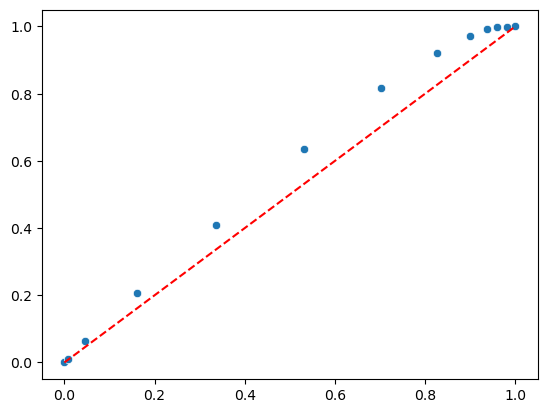

In [93]:
recta_x = [i * 0.01 for i in range(101)]
recta_y = recta_x

sns.lineplot(x = recta_x, y = recta_y, ls = "--",  color = "red")
sns.scatterplot(x = especificidad_inv, y = sensibilidad)

## 18. Calcular el area bajo la curva

In [94]:
roc_auc = roc_auc_score(y_test, y_pred_proba)
roc_auc

np.float64(0.5736747184043289)